**What we not to do during Weight Initialization**

1. Zero weight Initialization : due to no training of neural networks
2. Non Zero weight Initialization: model will behave like linear and unable to capture pattern in non linear data
3. Random Initialization with small Weights: duet to vanishing gradient problem and slow convergence problem.
4. Random Initialization with large Weights: VGP (when activation is tanh, sigmoid) and Exploding Gradient Problem (when activation function is ReLu)

**What can be Done for Weight Initialization ?**

Xavier / Glorat Weight initialization method:
    
* Suitable for tanh, sigmoid, Softmax activation function , it's give better       result.
* Variance for Xavier (Normal) = 2/ ( fan_in + fan_out )
* Variance for Xavier (Uniform) = 6/ ( fan_in + fan_out )

    Where 
    1. fan_in ---> number of input coming to the node
    2. fan_out ---> number of output from the current node

**Xavier / Glorat Weights initialization method:**

* Suitable for ReLU, Leaky ReLU, ELU activation function , it's give better result.
* Variance for Xavier (Normal) = 2/ fan_in
* Variance for Xavier (Uniform) = 6/ fan_in


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hafeezabro/ushape/ushape.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/kaggle/input/datasets/hafeezabro/ushape/ushape.csv')

In [5]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


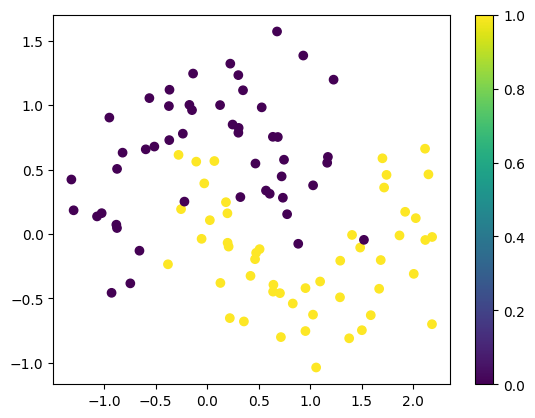

In [6]:
df.columns = ['X','Y','class']
plt.scatter(df['X'],df['Y'],c=df['class'])
plt.colorbar()
plt.show()

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.get_weights()

[array([[ 0.05152202,  0.11210454,  0.64505464, -0.6371088 ,  0.41933483,
         -0.31706583,  0.4413343 , -0.49317664, -0.19829822, -0.39048633],
        [-0.0087952 , -0.0163331 ,  0.16254067,  0.57361084,  0.39794225,
          0.35526067,  0.50963324,  0.547689  ,  0.08858627,  0.61141723]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.04705894,  0.02664346,  0.07599384, -0.49624848,  0.5382005 ,
          0.36184168,  0.27897573, -0.41455013, -0.45783404,  0.04809761],
        [ 0.523798  ,  0.13092321,  0.06690347, -0.41023052, -0.04662186,
          0.32242447, -0.5441249 ,  0.00219476,  0.03040397,  0.1046291 ],
        [-0.11231142, -0.25310758, -0.2869067 , -0.12527078,  0.2160567 ,
         -0.48165613, -0.0593605 ,  0.5073997 ,  0.19579339, -0.3655581 ],
        [ 0.19681847,  0.52904344, -0.33537272, -0.45543176, -0.11281195,
         -0.24371994, -0.38439804, -0.12055448, -0.24106431, -0.4670028 ],
        [-0.49015

In [13]:
initial_weights = model.get_weights()

In [14]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [15]:
model.set_weights(initial_weights)

In [16]:
model.get_weights()

[array([[-0.03467712,  0.17267203, -0.30441877, -1.0798215 ,  0.3456653 ,
          0.17920089, -0.01633862,  0.13501303, -0.27330726, -0.70471144],
        [ 1.868563  , -1.8981608 ,  0.21205674, -1.8314182 ,  0.17839189,
          0.96439904, -0.53797686,  0.46863493, -1.5252125 ,  1.0447493 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.54329985, -0.31687996,  0.3127805 , -0.17833127,  0.3044423 ,
         -0.35882252,  0.2249449 ,  0.28354865, -0.6282141 , -0.31106097],
        [ 0.0343453 ,  0.48670974,  0.3651749 , -0.3215966 ,  0.08126443,
         -0.03471872, -0.61388165,  0.13656059, -0.4473511 , -0.12640141],
        [ 0.02473276, -0.5893566 , -0.17947055,  0.09319842,  0.08440769,
         -0.22944888, -0.2534874 , -0.42014828, -0.1765385 , -0.13592172],
        [ 0.36315346,  0.46815816, -0.7265341 ,  0.32414448,  0.40921837,
         -0.08913643,  0.28273994,  0.00696602, -0.43316555,  0.17021614],
        [-0.15959

In [17]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [18]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.3867 - loss: 0.7618 - val_accuracy: 0.5500 - val_loss: 0.7235
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4110 - loss: 0.7298 - val_accuracy: 0.6000 - val_loss: 0.7005
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3846 - loss: 0.7333 - val_accuracy: 0.7000 - val_loss: 0.6788
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5100 - loss: 0.6919 - val_accuracy: 0.7000 - val_loss: 0.6580
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5943 - loss: 0.6816 - val_accuracy: 0.7500 - val_loss: 0.6387
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6182 - loss: 0.6647 - val_accuracy: 0.8500 - val_loss: 0.6203
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7099 - loss: 0.6429 - val_accuracy: 0.8500 - val_loss: 0.6022
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7265 - loss: 0.6265 - val_accuracy: 0.8500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

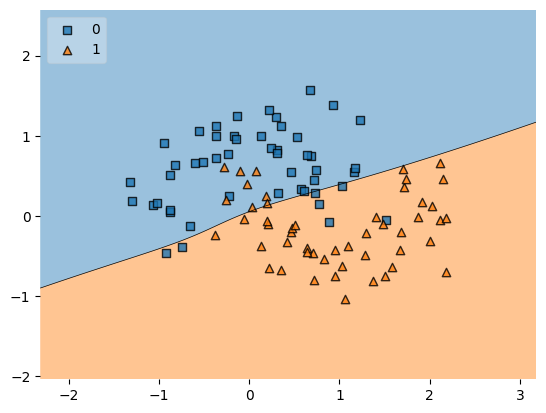

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)

**He weight Initialization** 

In [21]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:

inital_weights = model.get_weights()
model.set_weights(initial_weights)
model.get_weights

<bound method Layer.get_weights of <Sequential name=sequential_3, built=True>>

In [26]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.4773 - loss: 0.6793 - val_accuracy: 0.5000 - val_loss: 0.6692
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4929 - loss: 0.6793 - val_accuracy: 0.5000 - val_loss: 0.6660
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4851 - loss: 0.6763 - val_accuracy: 0.5000 - val_loss: 0.6626
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4890 - loss: 0.6705 - val_accuracy: 0.5000 - val_loss: 0.6587
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4851 - loss: 0.6694 - val_accuracy: 0.5000 - val_loss: 0.6545
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5149 - loss: 0.6625 - val_accuracy: 0.5000 - val_loss: 0.6498
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5344 - loss: 0.6605 - val_accuracy: 0.5000 - val_loss: 0.6447
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5056 - loss: 0.6627 - val_accuracy: 0.5500 - val_loss

model weights gets changed

In [27]:
model.get_weights()

[array([[-0.06738099,  0.4419424 , -0.13796544, -1.3017035 ,  0.48293948,
          0.09746625,  0.0937227 ,  0.03197289, -0.3305692 , -0.76884645],
        [ 2.0461254 , -2.1605287 ,  0.25759402, -1.7369119 ,  0.03998984,
          0.904884  , -0.59309924,  0.62896883, -1.6016958 ,  1.2393571 ]],
       dtype=float32),
 array([ 0.08868678,  0.2651406 , -0.15898265, -0.03701177,  0.14440595,
        -0.11320056,  0.07509382,  0.10295053,  0.19137362,  0.09778801],
       dtype=float32),
 array([[-0.36704785, -0.32506654,  0.18861899, -0.03874198,  0.44700807,
         -0.376346  ,  0.16012272,  0.44844416, -0.6282141 , -0.20789437],
        [-0.10748369,  0.76585484,  0.61697274, -0.4144749 , -0.00829468,
          0.22828788, -0.6183501 ,  0.04427814, -0.4473511 , -0.19784124],
        [ 0.20402703, -0.6609525 , -0.17947055,  0.26385188,  0.22156331,
         -0.1304987 , -0.32369363, -0.2762502 , -0.1765385 ,  0.03102445],
        [ 0.41192007,  0.47883156, -0.616606  ,  0.41504404, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

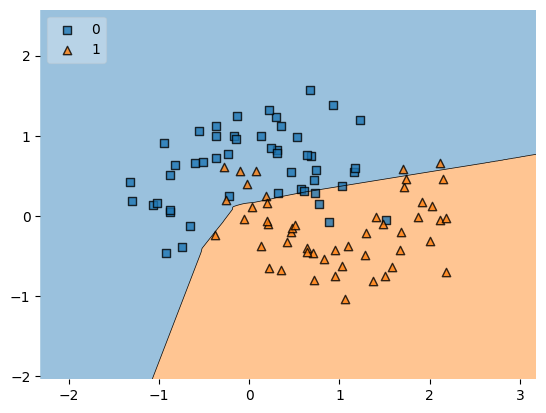

In [30]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)